# 监督学习
> 注意：本人为懒狗，文字概念、数学公式和绘图方法大量由ai生成
以下为分类任务目标
## 序和评估
1. 机器学习算法
2. 集成学习
3. 回归模型评估
4. 分类指标

## 回归算法
1. 线性回归
2. 多元线性回归
3. 多项式回归

## 分类算法
1. 逻辑回归
2. K近邻算法
3. 支持向量机
4. 决策树
5. 随机森林

## 序和评估
这一节将以文字和数学公式进行介绍

## 回归算法
这一段简述回归算法的概念和应用场景

### 线性回归
线性回归是一种基本的回归算法，用于预测连续数值型目标
$$
\hat{y} = \beta_0 + \beta_1 \hat{x}
$$

In [4]:
# 1. 导入数据处理与计算库
import numpy as np
import pandas as pd
# 2. 导入绘图库
import matplotlib.pyplot as plt
# 让 matplotlib 在 Jupyter 中内联显示，并支持中文标签（视操作系统而定，以下两行用于避免图表中文乱码）
%matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows常用
plt.rcParams['axes.unicode_minus'] = False 

# 3. 从 scikit-learn 导入数据集模块
from sklearn import datasets

# 4. 导入数据集
california = datasets.fetch_california_housing(as_frame=True)


print("基础库与数据集模块导入成功！")

基础库与数据集模块导入成功！


让我们看看这个数据集长什么样。我们打印前五行数据：


In [5]:
df = california.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


从左到右分别为
- 平均收入 (MedInc)
- 房屋年龄 (HouseAge)
- 平均房间数 (AveRooms)
- 平均卧室数 (AveBedrms)
- 人口数量 (Population)
- 家庭数量 (AveOccup)
- 经度 (Longitude)
- 纬度 (Latitude)
- 目标变量：房价中位数 (MedHouseVal)
我们可以作一个最基本的假设：房价中位数与平均收入之间存在某种关系，而且很可能是线性的。


In [6]:
# 由于sklearn的庞大，我们只能以按需导入的方式使用
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# 提取数据并划分数据集和测试集
X = df[['MedInc']] # 特征变量必须是二维的，因此我们使用双重括号来选择列
y = df['MedHouseVal']  # 目标变量

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 训练
linerModel = LinearRegression()
linerModel.fit(X_train, y_train)
# 预测和评估
y_pred = linerModel.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"均方误差: {mse:.2f}\nR²得分: {r2:.2f}\nfunction: y = {linerModel.coef_[0]:.2f} * x + {linerModel.intercept_:.2f}")


均方误差: 0.71
R²得分: 0.46
function: y = 0.42 * x + 0.44


尽管还没有绘图，也能看出效果非常差（这个$R^2$感觉不如撒一把豆子随手画条线） 

但我们还是画一下

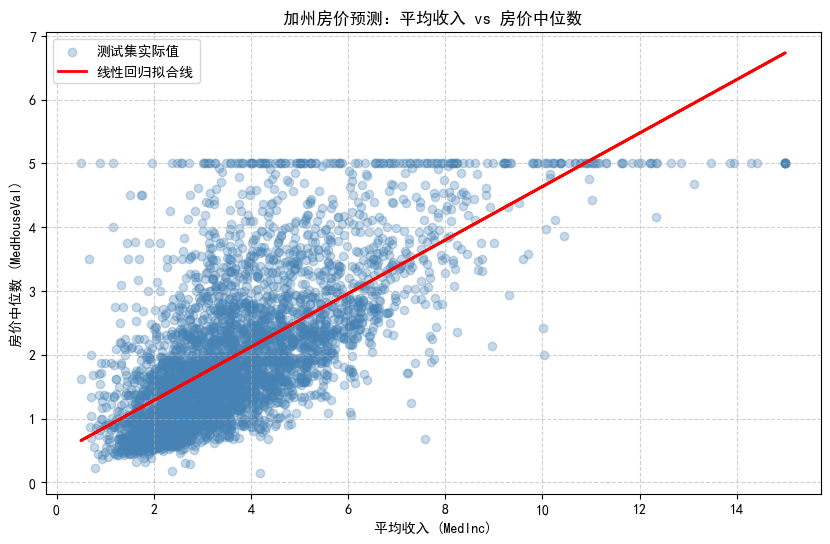

In [7]:
# 创建一块画布
plt.figure(figsize=(10, 6))

# 绘制测试集的实际数据散点 (使用较浅的颜色，方便看清高密度区域)
plt.scatter(X_test, y_test, color='steelblue', alpha=0.3, label='测试集')

# 绘制模型预测出的那条“直线”
plt.plot(X_test, y_pred, color='red', linewidth=2, label='拟合线')

# 添加图表信息
plt.xlabel('平均收入 (MedInc)')
plt.ylabel('房价中位数 (MedHouseVal)')
plt.title('加州房价预测：平均收入 vs 房价中位数')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 显示图像
plt.show()

注意到存在数据截断问题，房价中位数被限制在了50万美元。也许其实没有并那么差。

下一个的方法中，我们会剔除掉这些数据。

### 多元线性回归
多元线性回归是线性回归的扩展，允许我们使用多个特征来预测目标变量
$$
\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n
$$

In [10]:
# 剔除房价中位数为 5.0 (50万美元) 的数据点，避免数据截断带来的影响
df_filtered = df[df['MedHouseVal'] < 5.0]

# 提取特征变量(多个特征)和目标变量
X = df_filtered[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Longitude', 'Latitude']]
y = df_filtered['MedHouseVal']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 构建和训练多元线性回归模型
linerNModel = LinearRegression()
linerNModel.fit(X_train, y_train)

# 预测和评估
y_pred = linerNModel.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"均方误差: {mse:.4f}\nR²得分: {r2:.4f}\n各项特征系数: {np.round(linerNModel.coef_, 4)}")

均方误差: 0.4133
R²得分: 0.5689
各项特征系数: [ 0.4283  0.008  -0.1036  0.5788  0.     -0.0031 -0.3922 -0.3758]
